In [1]:
import sys
print(sys.executable)

c:\Users\stephane.holtzmann\AppData\Local\anaconda3\envs\dl_env\python.exe


In [2]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Activation
from keras.optimizers import SGD
from keras.utils import to_categorical

nb_classes = 10 #On doit reconnaitre 10 chiffres différents

(training_images, training_labels), (test_images, test_labels) = mnist.load_data()
print ('Apprentissage : ', training_images.shape[0])
print ('Test : ', test_images.shape[0])

Apprentissage :  60000
Test :  10000


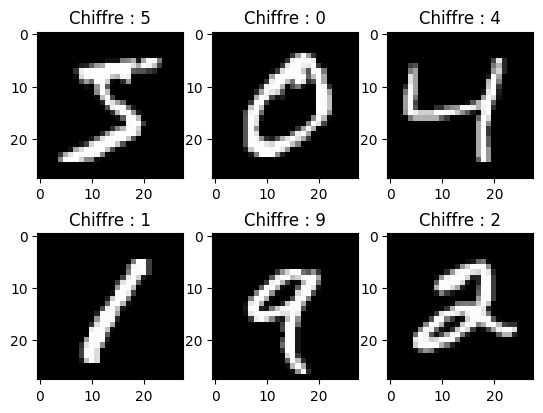

In [4]:


for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(training_images[i], cmap='gray', interpolation='none')
    plt.title("Chiffre : {}".format(training_labels[i]))



In [5]:
training_images = training_images.reshape(60000, 784)
test_images = test_images.reshape(10000, 784)
training_images = training_images.astype('float32')
test_images = test_images.astype('float32')
training_images /= 255
test_images /= 255

from tensorflow.keras.utils import to_categorical

In [10]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import SGD

training_labels_categories = keras.utils.to_categorical(training_labels, 10)
test_labels_categories = keras.utils.to_categorical(test_labels, 10)

model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(500, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(
    loss="categorical_crossentropy",
    optimizer=SGD(learning_rate=0.5),
    metrics=["accuracy"]
)

history = model.fit(
    training_images,
    training_labels_categories,
    batch_size=500,
    epochs=1,
    verbose=1,
    validation_data=(test_images, test_labels_categories)
)

score = model.evaluate(test_images, test_labels_categories, verbose=0)
print("Score sur le dataset de test :", score[1] * 100, "%")

120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8617 - loss: 0.4637 - val_accuracy: 0.9271 - val_loss: 0.2531
Score sur le dataset de test : 92.71000027656555 %


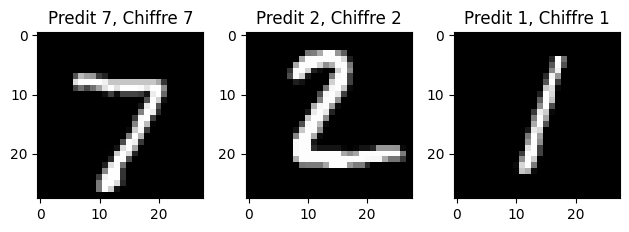

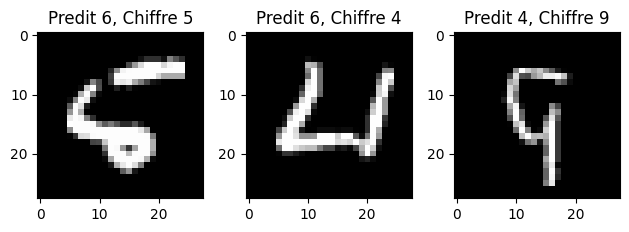

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Probabilités (shape: [n, 10])
y_proba = model.predict(test_images, verbose=0)

# Classes prédites (shape: [n])
classes_predites = np.argmax(y_proba, axis=1)

correct_indices = np.where(classes_predites == test_labels)[0]
incorrect_indices = np.where(classes_predites != test_labels)[0]

plt.figure()
for i, idx in enumerate(correct_indices[:3]):
    plt.subplot(1, 3, i + 1)
    plt.imshow(test_images[idx].reshape(28, 28), cmap="gray", interpolation="none")
    plt.title(f"Predit {classes_predites[idx]}, Chiffre {test_labels[idx]}")
plt.tight_layout()

plt.figure()
for i, idx in enumerate(incorrect_indices[:3]):
    plt.subplot(1, 3, i + 1)
    plt.imshow(test_images[idx].reshape(28, 28), cmap="gray", interpolation="none")
    plt.title(f"Predit {classes_predites[idx]}, Chiffre {test_labels[idx]}")
plt.tight_layout()



In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense

x = np.random.random((1, 2))

dense = Dense(3) 

y = dense(x)
W, b = dense.get_weights()

print("Entrée :", x)
print("Matrice W :\n", W)
print("Biais b :", b)
print("Sortie :", y.numpy())


Entrée : [[0.14415362 0.5102289 ]]
Matrice W :
 [[-0.05303717 -0.20609432 -0.5780332 ]
 [-0.12280816 -1.050846   -0.8567847 ]]
Biais b : [0. 0. 0.]
Sortie : [[-0.07030576 -0.5658812  -0.5204819 ]]


NameError: name 'y' is not defined